In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

# Generate synthetic regression data with multiple features
X, y = make_regression(n_samples=500, n_features=20, n_informative=10, noise=0.1, random_state=42)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Dataset ready! Train shape:", X_train.shape)

Dataset ready! Train shape: (400, 20)


In [2]:
# Initialize models with specific alpha (regularisation strength) values
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (L2)": Ridge(alpha=1.0),
    "Lasso (L1)": Lasso(alpha=0.1),
    "Elastic Net": ElasticNet(alpha=0.1, l1_ratio=0.5)
}

results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "MSE": mse, "R2 Score": r2})
    print(f"--- {name} ---")
    print(f"MSE: {mse:.4f} | R2 Score: {r2:.4f}\n")

# Summary DataFrame
results_df = pd.DataFrame(results)
print(results_df)

--- Linear Regression ---
MSE: 0.0097 | R2 Score: 1.0000

--- Ridge (L2) ---
MSE: 0.1924 | R2 Score: 1.0000

--- Lasso (L1) ---
MSE: 0.1125 | R2 Score: 1.0000

--- Elastic Net ---
MSE: 60.7421 | R2 Score: 0.9967

               Model        MSE  R2 Score
0  Linear Regression   0.009686  0.999999
1         Ridge (L2)   0.192364  0.999989
2         Lasso (L1)   0.112454  0.999994
3        Elastic Net  60.742130  0.996681


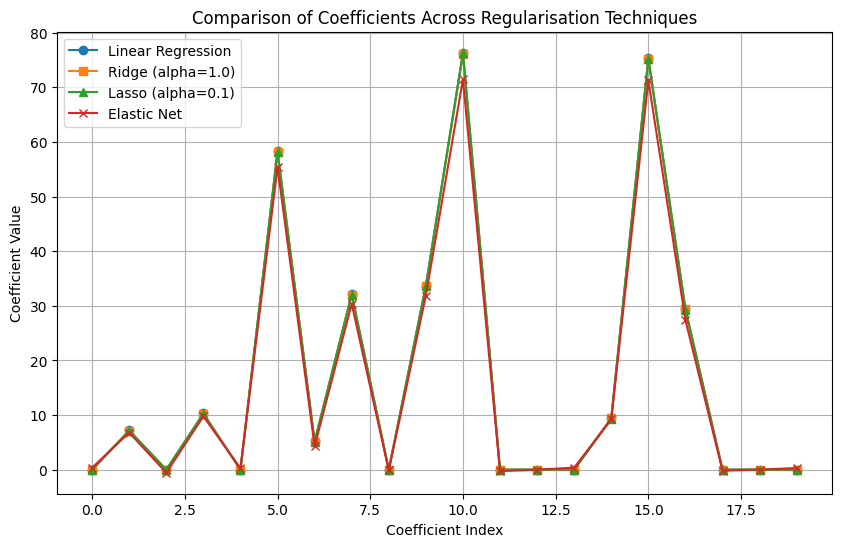

In [3]:
plt.figure(figsize=(10, 6))

plt.plot(models["Linear Regression"].coef_, label='Linear Regression', marker='o')
plt.plot(models["Ridge (L2)"].coef_, label='Ridge (alpha=1.0)', marker='s')
plt.plot(models["Lasso (L1)"].coef_, label='Lasso (alpha=0.1)', marker='^')
plt.plot(models["Elastic Net"].coef_, label='Elastic Net', marker='x')

plt.xlabel('Coefficient Index')
plt.ylabel('Coefficient Value')
plt.title('Comparison of Coefficients Across Regularisation Techniques')
plt.legend()
plt.grid(True)
plt.show()